In [1]:
import os
from os.path import splitext

import rasterio
import geopandas as gpd 
import matplotlib.pyplot as plt
import rioxarray as rxr
from numpy import dtype
from rasterio.mask import mask
import matplotlib.ticker as ticker
import glob
from datetime import datetime
import pandas as pd
from metloom.pointdata import SnotelPointData

import numpy as np
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [6]:
dir = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"

raster_dict = {}
for root, dirs, files in os.walk(dir):
    for filename in files:
        if "50m_clip" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict[name] = os.path.abspath(full_path)

print(raster_dict)

{'20251203': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251203_MCS_50m_clip.tif', '20251213': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251213_MCS_50m_clip.tif', '20251220': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251220_MCS_50m_clip.tif', '20260110': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260110_MCS_50m_clip.tif', '20260126': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260126_MCS_50m_clip.tif', '20260131': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260131_MCS_50m_clip.tif', '20260207': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260207_MCSv2_50m_clip.tif', '20260222': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260222_MCS_50m_clip.tif', '20260226': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260226_MCS_50m_clip.tif', '20260303': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260303_MCS_50m_clip.tif', '20260315': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260315_MCS_50m_clip.tif'}


In [16]:
for i, (date, raster) in enumerate(raster_dict.items()):
    print(os.path.join(dir, raster))
    print(type(raster))
    with rasterio.open(os.path.join(dir, raster)) as src:
        print(src.crs)

C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251203_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251213_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251220_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260110_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260126_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260131_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260207_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260222_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260226_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260303_MCS_50m_clip.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260315_MCS_50m_clip.tif
<class 'str'>

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29912\1840534821.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


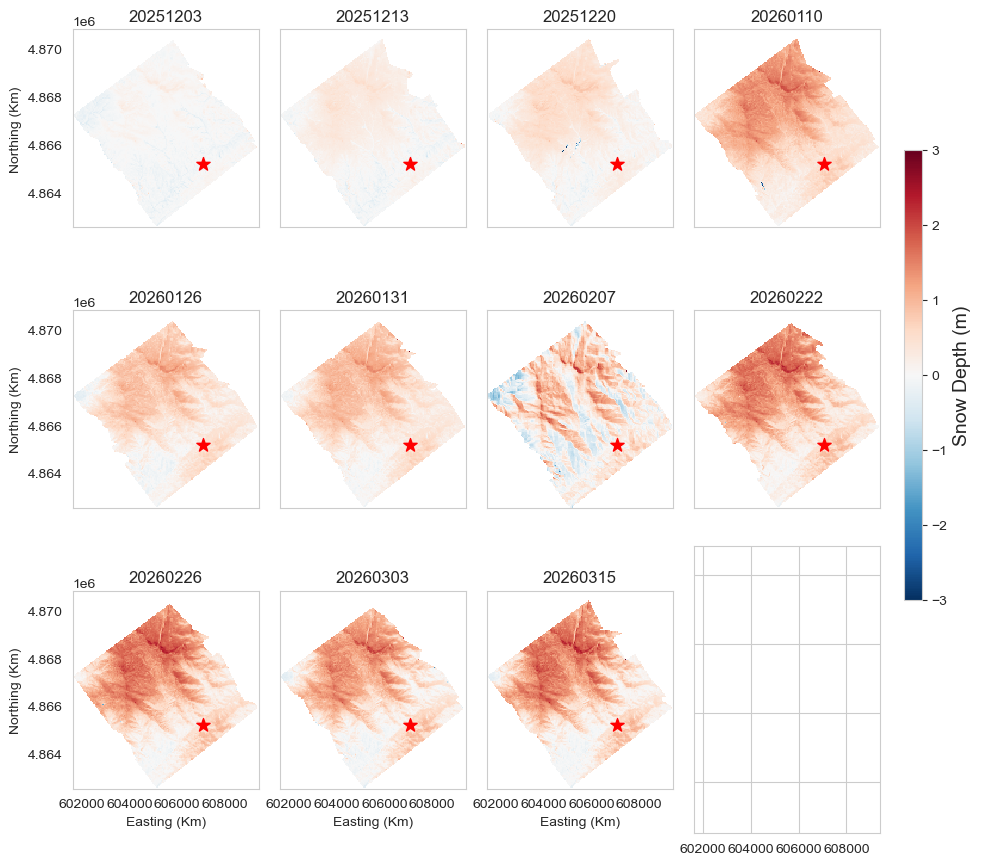

In [17]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

vcenter = 0
vmin = -3
vmax = 3
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(9,9), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict.items()):
    if i < len(raster_dict.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        snow_depth = snow_depth.where(snow_depth > -5)
        im = snow_depth.plot(ax=ax, cmap=colormap, vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29912\221566922.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


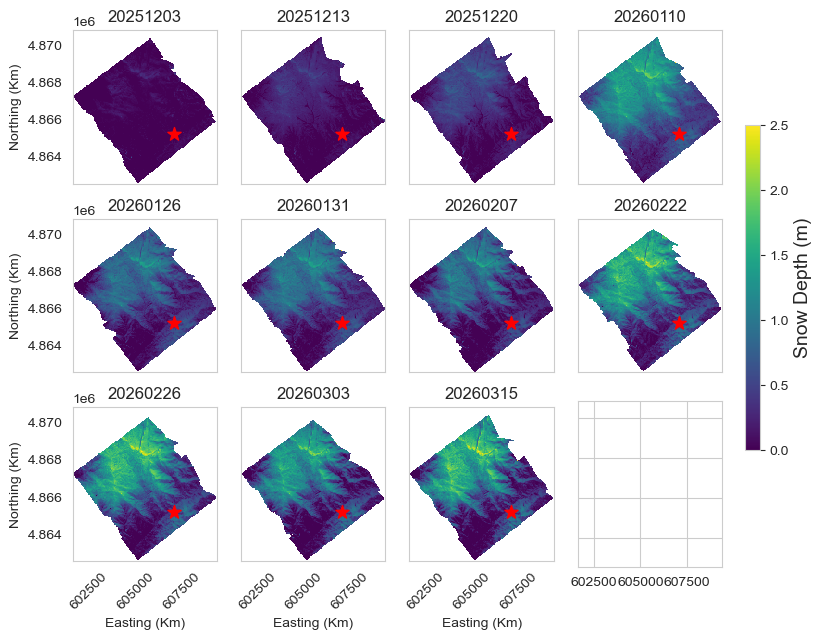

In [21]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

vmin = 0
vmax = 2.5


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(7.5,6.5), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict.items()):
    if i < len(raster_dict.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        im = snow_depth.plot(ax=ax, cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.tick_params(axis='x', labelrotation=45)
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()

In [22]:
dir = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"

raster_dict_full = {}
for root, dirs, files in os.walk(dir):
    for filename in files:
        if "50m.tif" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict_full[name] = os.path.abspath(full_path)

print(raster_dict_full)

{'20251203': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251203_MCS-snowdepth_master_50m.tif', '20251213': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251213_MCS-snowdepth_master_50m.tif', '20251220': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251220_MCS-snowdepth_master_50m.tif', '20260110': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260110_MCS-snowdepth_master_rerun_50m.tif', '20260126': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260126_MCS-snowdepth_master_50m.tif', '20260131': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260131_MCS-snowdepth_master_50m.tif', '20260207': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260207_MCSv2-snowdepth_master_50m.tif', '20260222': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260222_MCS-snowdepth_master_50m.tif', '20260226': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260226_MCS-snowdepth_master_50m.tif', '20260303': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260303_MCS-snowdepth_master_5

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_29912\1947787835.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


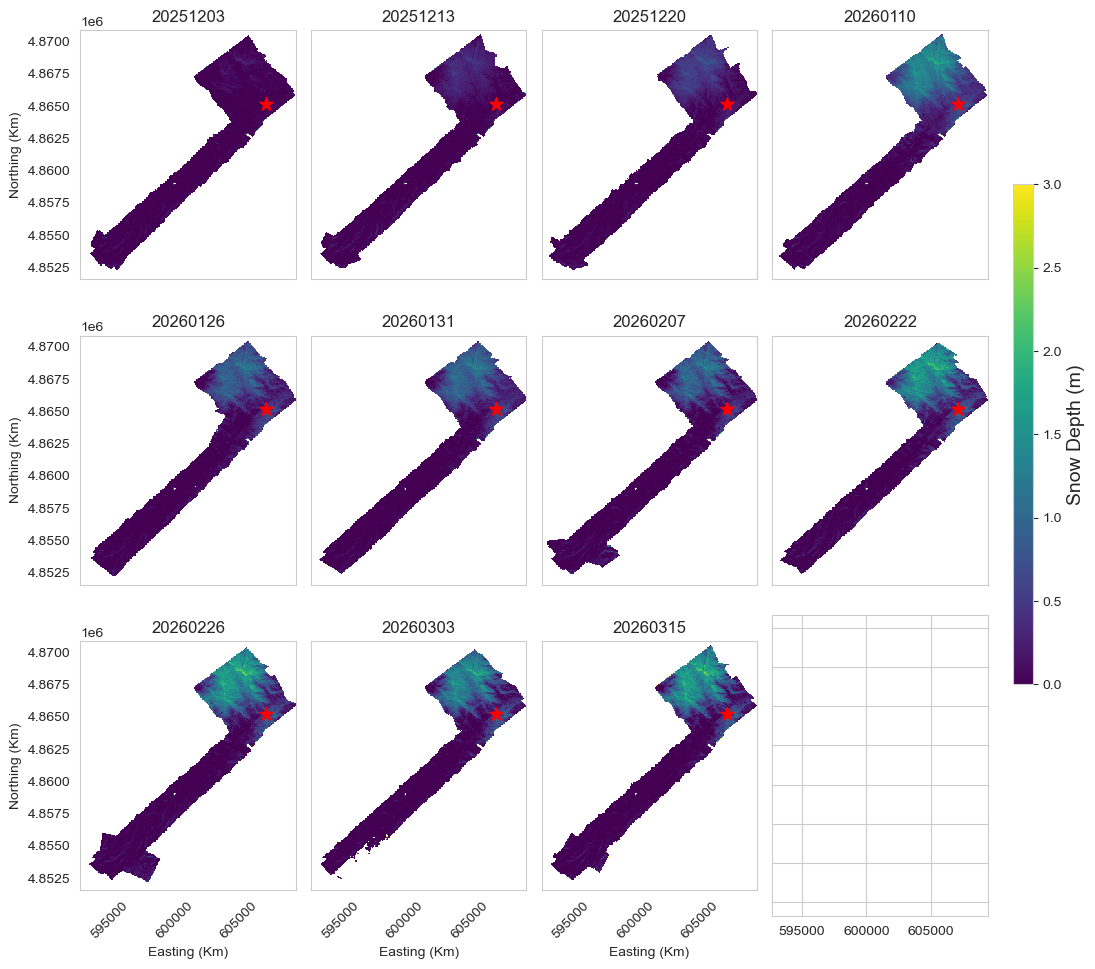

In [23]:

vmin = 0
vmax = 3


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 10), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict_full.items()):
    if i < len(raster_dict_full.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        im = snow_depth.plot(ax=ax, cmap='viridis', vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.tick_params(axis='x', labelrotation=45)
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()

In [3]:

snotel_point = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
WY26 = snotel_point.get_daily_data(datetime(2025, 10, 1), datetime(2026, 3, 30),
                                    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
WY26['SNOWDEPTH (m)'] = WY26['SNOWDEPTH'] * 0.0254
WY26['Date (MM-DD)'] = WY26.index.strftime('%m-%d') #add a new column (Date (MM-DD)) to the dataframe
WY26.index = WY26.index.strftime('%Y-%m-%d')


In [4]:
WY26

,site,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m),Date (MM-DD)
datetime,,,,,,,
2025-10-01,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0000,10-01
2025-10-02,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0000,10-02
2025-10-03,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),1.0,in,NRCS,0.0254,10-03
2025-10-04,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0000,10-04
2025-10-05,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0000,10-05
...,...,...,...,...,...,...,...
2026-03-26,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),24.0,in,NRCS,0.6096,03-26
2026-03-27,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),23.0,in,NRCS,0.5842,03-27
2026-03-28,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),21.0,in,NRCS,0.5334,03-28


In [8]:
df = pd.DataFrame(raster_dict.items(), columns=['Filename', 'Filepath'])
df['Date'] = pd.to_datetime(df['Filename'], format='%Y%m%d')
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')
df.set_index('Date', inplace=True)
df = pd.concat([df, WY26], axis=1, join='inner')


In [16]:

lidar_mean = []
lidar_std = []
lidar_median = []
lidar_iqr = []


for filename, raster in raster_dict.items():
        sd = rxr.open_rasterio(raster, masked = True)   
        date = pd.to_datetime(filename, format='%Y%m%d') 
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))
        lidar_median.append(round(sd.median().item(), 2))
        q75 = sd.quantile(0.75, dim=("x", "y"))
        q25 = sd.quantile(0.25, dim=("x", "y"))
        iqr = q75 - q25
        lidar_iqr.append(iqr)
        
    #add the lidar mean and std to the snotel dataframe
df['LiDAR Mean (m)'] = lidar_mean
df['LiDAR Std (m)'] = lidar_std
df['Mean Difference (m)'] = df['SNOWDEPTH (m)'] - df['LiDAR Mean (m)']
df['LiDAR Median (m)'] = lidar_median
df['IQR (m)'] = lidar_iqr


    #find the difference between the snotel and lidar
#df['Mean Difference (m)'] = df['Snow Depth (m)'] - df['LiDAR Mean (m)']


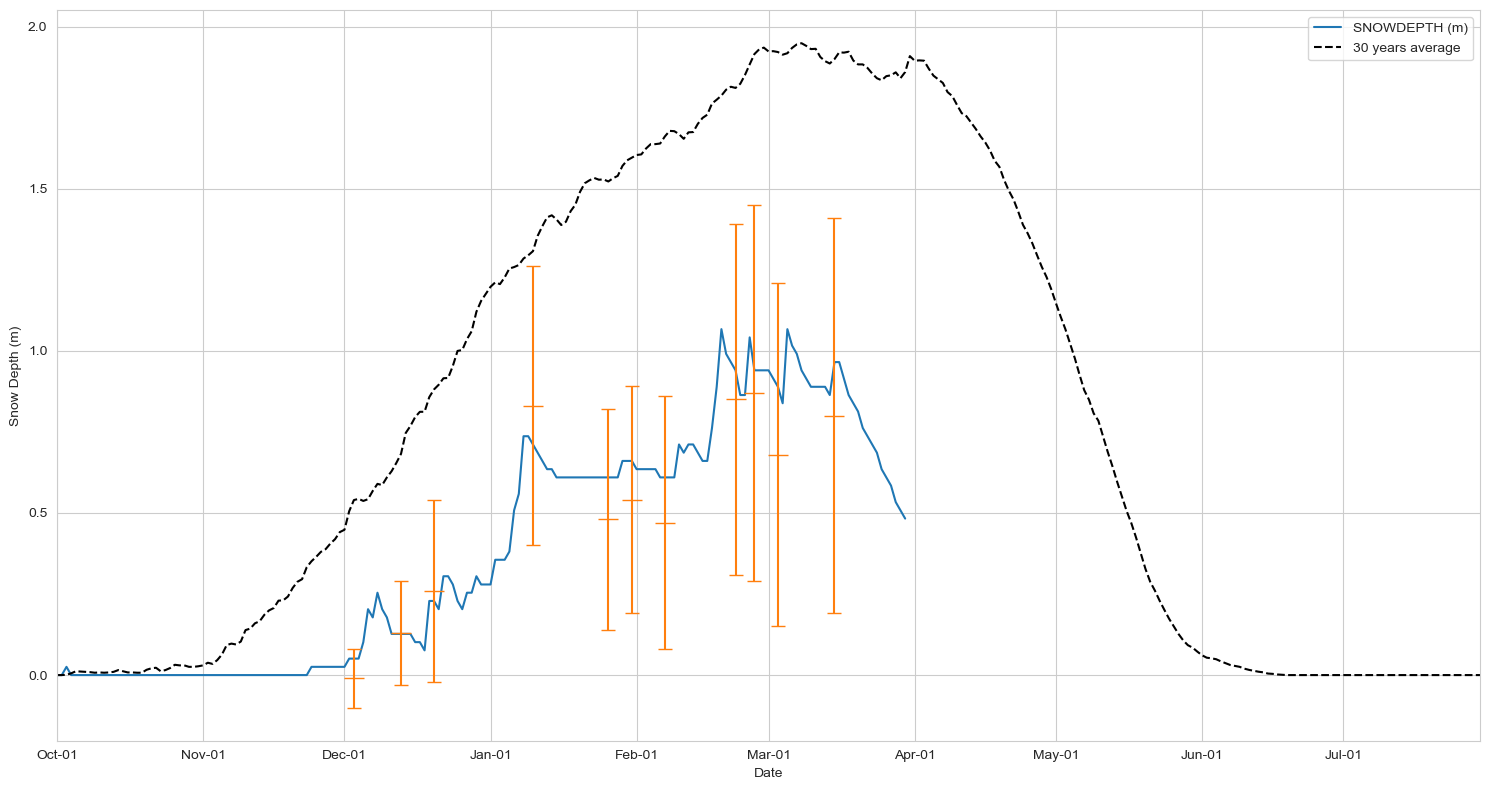

In [13]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(WY26['Date (MM-DD)'], WY26['SNOWDEPTH (m)'], label='SNOWDEPTH (m)')
ax.errorbar(x= df['Date (MM-DD)'], y=df['LiDAR Mean (m)'], yerr=df['LiDAR Std (m)'], linestyle='none', marker='_', markersize =  15, capsize=5)

data_DDD = snotel_point.get_daily_data(datetime(1993, 10, 1), datetime(2026, 3, 30),
                                       [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
data_DDD['SNOWDEPTH (m)'] = data_DDD['SNOWDEPTH'] * 0.0254 #convert to meters
data_DDD.reset_index(inplace=True)
data_DDD['datetime'] = pd.to_datetime(data_DDD['datetime'])
data_DDD['day_of_year'] = data_DDD['datetime'].dt.dayofyear #add a new column (day_of_year) to the dataframe
data_DDD['year'] = data_DDD['datetime'].dt.year #add a new column (year) to the dataframe
daily_avg_snowdepth = data_DDD.groupby('day_of_year')['SNOWDEPTH (m)'].mean() #calculate the daily average snowdepth
daily_avg_snowdepth = daily_avg_snowdepth.reset_index() #reset the index
daily_avg_snowdepth['MM-DD'] = pd.to_datetime(daily_avg_snowdepth['day_of_year'], format='%j').dt.strftime('%m-%d') #add a new column (MM-DD) to the dataframe
daily_avg_snowdepth.set_index('MM-DD', inplace=True) #set the index to the YYYY-MM-DD column
#remove the last two rows (There is repetition of 01:01)
daily_avg_snowdepth = daily_avg_snowdepth[:-2]
#break the dataframe to two. Onw with records starting from 10-01 to 12-31 and the other from 01-01 to 09-30. Then combine them
daily_avg_snowdepth1 = daily_avg_snowdepth['10-01':'12-31']
daily_avg_snowdepth2 = daily_avg_snowdepth['01-01':'09-30']
daily_avg_snowdepth = pd.concat([daily_avg_snowdepth1, daily_avg_snowdepth2])
ax.plot(daily_avg_snowdepth.index, daily_avg_snowdepth['SNOWDEPTH (m)'], label='30 years average', linestyle='dashed', color='black')

    # Create major ticks for the first day of each month and minor ticks for the middle (day 15) of each month
major_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-01')]
minor_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-15')]
# Define a dictionary to map month numbers to their abbreviated names
month_map = {
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dec',
    '01': 'Jan',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Apr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Aug',
    '09': 'Sep'
}

# Create a new label format for the x-axis
new_labels = [month_map[date.split('-')[0]] + '-' + date.split('-')[1] for date in major_ticks]

# Set the major and minor ticks for the x-axis
plt.xticks(ticks = major_ticks, labels = new_labels)
plt.gca().set_xticks(minor_ticks, minor=True)

# # Display grid for both major and minor ticks
# plt.grid(which='both')
# plt.grid(which='both', alpha=0.2)

#set the xlimt
ax.set_xlim('10-01', '07-30')
# Add a legend
ax.legend()
#set axis label
ax.set_ylabel('Snow Depth (m)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()



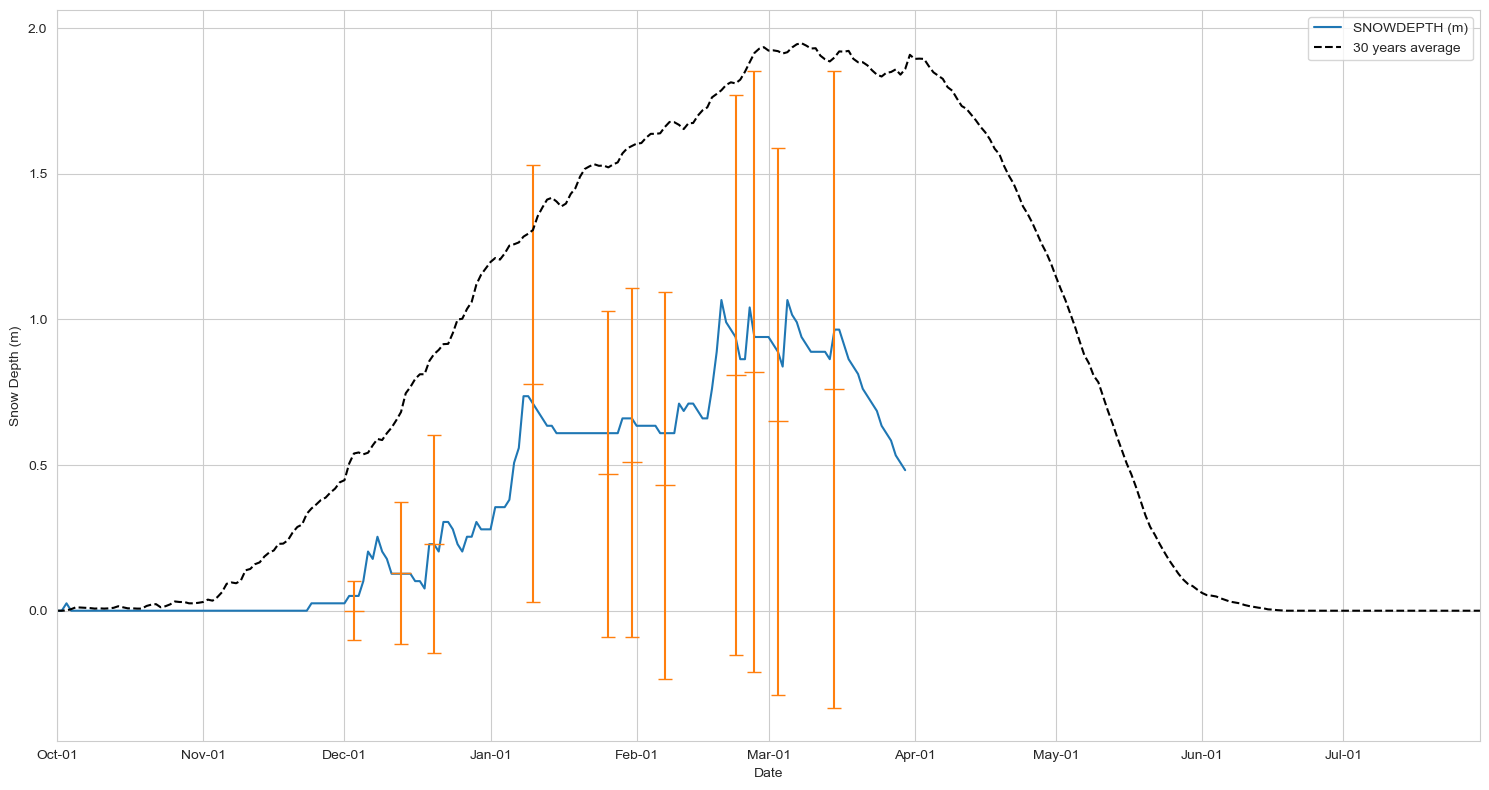

In [14]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(WY26['Date (MM-DD)'], WY26['SNOWDEPTH (m)'], label='SNOWDEPTH (m)')
ax.errorbar(x= df['Date (MM-DD)'], y=df['LiDAR Median (m)'], yerr=df['IQR (m)'], linestyle='none', marker='_', markersize =  15, capsize=5)

data_DDD = snotel_point.get_daily_data(datetime(1993, 10, 1), datetime(2026, 3, 30),
                                       [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
data_DDD['SNOWDEPTH (m)'] = data_DDD['SNOWDEPTH'] * 0.0254 #convert to meters
data_DDD.reset_index(inplace=True)
data_DDD['datetime'] = pd.to_datetime(data_DDD['datetime'])
data_DDD['day_of_year'] = data_DDD['datetime'].dt.dayofyear #add a new column (day_of_year) to the dataframe
data_DDD['year'] = data_DDD['datetime'].dt.year #add a new column (year) to the dataframe
daily_avg_snowdepth = data_DDD.groupby('day_of_year')['SNOWDEPTH (m)'].mean() #calculate the daily average snowdepth
daily_avg_snowdepth = daily_avg_snowdepth.reset_index() #reset the index
daily_avg_snowdepth['MM-DD'] = pd.to_datetime(daily_avg_snowdepth['day_of_year'], format='%j').dt.strftime('%m-%d') #add a new column (MM-DD) to the dataframe
daily_avg_snowdepth.set_index('MM-DD', inplace=True) #set the index to the YYYY-MM-DD column
#remove the last two rows (There is repetition of 01:01)
daily_avg_snowdepth = daily_avg_snowdepth[:-2]
#break the dataframe to two. Onw with records starting from 10-01 to 12-31 and the other from 01-01 to 09-30. Then combine them
daily_avg_snowdepth1 = daily_avg_snowdepth['10-01':'12-31']
daily_avg_snowdepth2 = daily_avg_snowdepth['01-01':'09-30']
daily_avg_snowdepth = pd.concat([daily_avg_snowdepth1, daily_avg_snowdepth2])
ax.plot(daily_avg_snowdepth.index, daily_avg_snowdepth['SNOWDEPTH (m)'], label='30 years average', linestyle='dashed', color='black')

    # Create major ticks for the first day of each month and minor ticks for the middle (day 15) of each month
major_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-01')]
minor_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-15')]
# Define a dictionary to map month numbers to their abbreviated names
month_map = {
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dec',
    '01': 'Jan',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Apr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Aug',
    '09': 'Sep'
}

# Create a new label format for the x-axis
new_labels = [month_map[date.split('-')[0]] + '-' + date.split('-')[1] for date in major_ticks]

# Set the major and minor ticks for the x-axis
plt.xticks(ticks = major_ticks, labels = new_labels)
plt.gca().set_xticks(minor_ticks, minor=True)

# # Display grid for both major and minor ticks
# plt.grid(which='both')
# plt.grid(which='both', alpha=0.2)

#set the xlimt
ax.set_xlim('10-01', '07-30')
# Add a legend
ax.legend()
#set axis label
ax.set_ylabel('Snow Depth (m)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()



In [ ]:
print(major_ticks)
print(minor_ticks)
print()